# NBA Player Performance Analysis

This notebook analyzes NBA player statistics using Python, pandas, Matplotlib and Seaborn.

The goal is to understand what factors are associated with player scoring performance, especially the relationship between points scored, playing time and efficiency.

## 1. Import Libraries

The analysis uses pandas for data manipulation, Matplotlib and Seaborn for visualization.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

## 2. Load Dataset

The dataset is loaded from the `data` folder. Each row represents one NBA player and includes performance metrics such as points, minutes, assists, rebounds, field goal percentage and efficiency.

In [2]:
df = pd.read_csv('../data/nba_player_stats_2026.csv')

df.head()

,PLAYER_ID,RANK,PLAYER,TEAM_ID,TEAM,GP,MIN,FGM,FGA,FG_PCT,FG3M,FG3A,FG3_PCT,FTM,FTA,FT_PCT,OREB,DREB,REB,AST,STL,BLK,TOV,PF,PTS,EFF,AST_TOV,STL_TOV
0,1629029,1,Luka Dončić,1610612747,LAL,64,2289,693,1457,0.476,254,694,0.366,503,645,0.780,41,454,495,530,105,34,255,153,2143,2146,2.08,0.41
1,1628983,2,Shai Gilgeous-Alexander,1610612760,OKC,68,2259,731,1321,0.553,115,298,0.386,540,614,0.879,38,254,292,448,95,52,151,139,2117,2189,2.97,0.63
2,1627759,3,Jaylen Brown,1610612738,BOS,71,2443,736,1543,0.477,140,404,0.347,426,536,0.795,81,411,492,364,72,27,259,191,2038,1817,1.41,0.28
3,201142,4,Kevin Durant,1610612745,HOU,78,2840,716,1376,0.520,186,450,0.413,408,467,0.874,41,385,426,372,62,71,246,142,2026,1992,1.51,0.25
4,1630178,5,Tyrese Maxey,1610612755,PHI,70,2661,694,1501,0.462,220,599,0.367,372,417,0.892,24,266,290,461,130,55,171,151,1980,1893,2.70,0.76


## 3. Explore Dataset Structure

This section checks the size of the dataset, available columns, data types and missing values.

In [3]:
print(f"Rows: {df.shape[0]}")
print(f"Columns: {df.shape[1]}")

pd.DataFrame({
    'Column': df.columns,
    'Data Type': [df[col].dtype for col in df.columns],
    'Missing Values': [df[col].isna().sum() for col in df.columns]
})

Rows: 582
Columns: 28


,Column,Data Type,Missing Values
0,PLAYER_ID,int64,0
1,RANK,int64,0
2,PLAYER,object,0
3,TEAM_ID,int64,0
4,TEAM,object,0
5,GP,int64,0
6,MIN,int64,0
7,FGM,int64,0
8,FGA,int64,0
9,FG_PCT,float64,0


## 4. Data Quality Check

The original dataset does not contain missing values. To demonstrate a realistic missing-value handling workflow, a separate copy is used for the example below. The main analysis dataset remains unchanged.

In [4]:
missing_summary = df.isna().sum().sort_values(ascending=False)
missing_summary[missing_summary > 0]

Series([], dtype: int64)

In [5]:
# Demonstration only: create missing values in a copy of the dataset.
# This avoids changing the real player statistics used in the analysis.
missing_demo = df.copy()
missing_demo.loc[0:20, 'PTS'] = None

before_fill = missing_demo['PTS'].isna().sum()
missing_demo['PTS'] = missing_demo['PTS'].fillna(missing_demo['PTS'].median())
after_fill = missing_demo['PTS'].isna().sum()

pd.DataFrame({
    'Step': ['Before fill', 'After fill'],
    'Missing PTS Values': [before_fill, after_fill]
})

,Step,Missing PTS Values
0,Before fill,21
1,After fill,0


## 5. Descriptive Statistics

The analysis focuses on the main player performance metrics: points, minutes, shooting percentage, assists, rebounds and efficiency.

In [6]:
performance_columns = ['PTS', 'MIN', 'FG_PCT', 'AST', 'REB', 'EFF']

df[performance_columns].describe().round(2)

,PTS,MIN,FG_PCT,AST,REB,EFF
count,582.00,582.00,582.00,582.00,582.00,582.00
mean,488.65,1019.79,0.46,113.03,185.01,563.67
std,459.78,771.98,0.10,121.80,167.26,501.76
min,0.00,3.00,0.00,0.00,0.00,-3.00
25%,107.00,293.25,0.42,21.25,49.00,133.25
50%,363.50,940.50,0.46,78.50,148.50,458.50
75%,759.00,1609.25,0.51,151.75,275.75,873.00
max,2143.00,2953.00,0.83,697.00,892.00,2665.00


## 6. Prepare Readable Column Names

A renamed copy of the dataset is created to make chart labels easier to read.

In [7]:
df_analysis = df.rename(columns={
    'PTS': 'Points',
    'MIN': 'Minutes',
    'FG_PCT': 'Field Goal %',
    'AST': 'Assists',
    'REB': 'Rebounds',
    'EFF': 'Efficiency'
})

## 7. Distribution of Points

The histogram shows how total points are distributed across players.

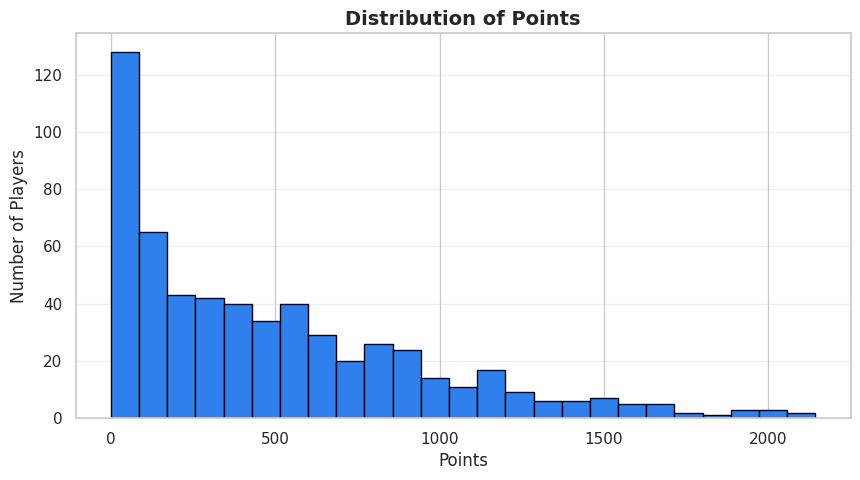

In [8]:
plt.figure(figsize=(10, 5))
plt.hist(df_analysis['Points'], bins=25, color='#2f80ed', edgecolor='black')
plt.title('Distribution of Points', fontsize=14, fontweight='bold')
plt.xlabel('Points')
plt.ylabel('Number of Players')
plt.grid(axis='y', alpha=0.3)
plt.show()

**Finding:** Most players score relatively low total points, while a smaller group of players achieve much higher scoring totals.

## 8. Relationship Between Minutes and Points

The scatter plot checks whether players who play more minutes tend to score more points.

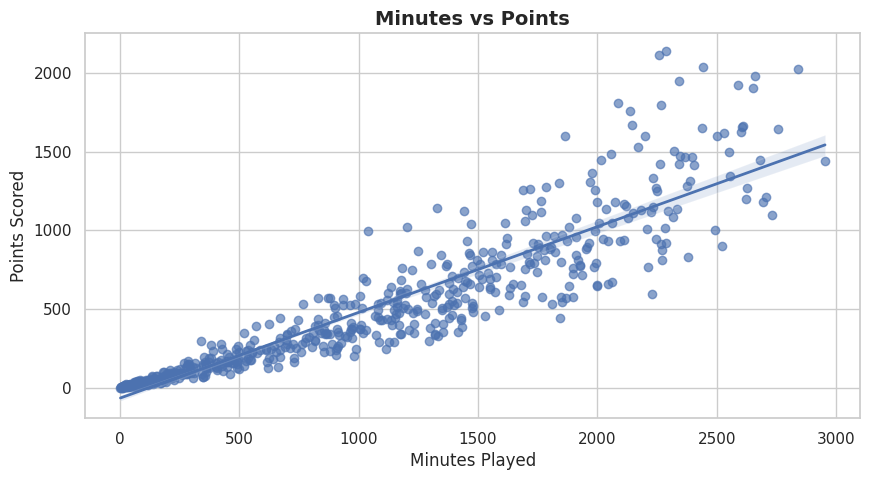

In [9]:
plt.figure(figsize=(10, 5))
sns.regplot(
    data=df_analysis,
    x='Minutes',
    y='Points',
    scatter_kws={'alpha': 0.65},
    line_kws={'linewidth': 2}
)
plt.title('Minutes vs Points', fontsize=14, fontweight='bold')
plt.xlabel('Minutes Played')
plt.ylabel('Points Scored')
plt.show()

**Finding:** There is a clear positive relationship between minutes played and points scored.

## 9. Top 10 Players by Points

This bar chart highlights the highest-scoring players in the dataset.

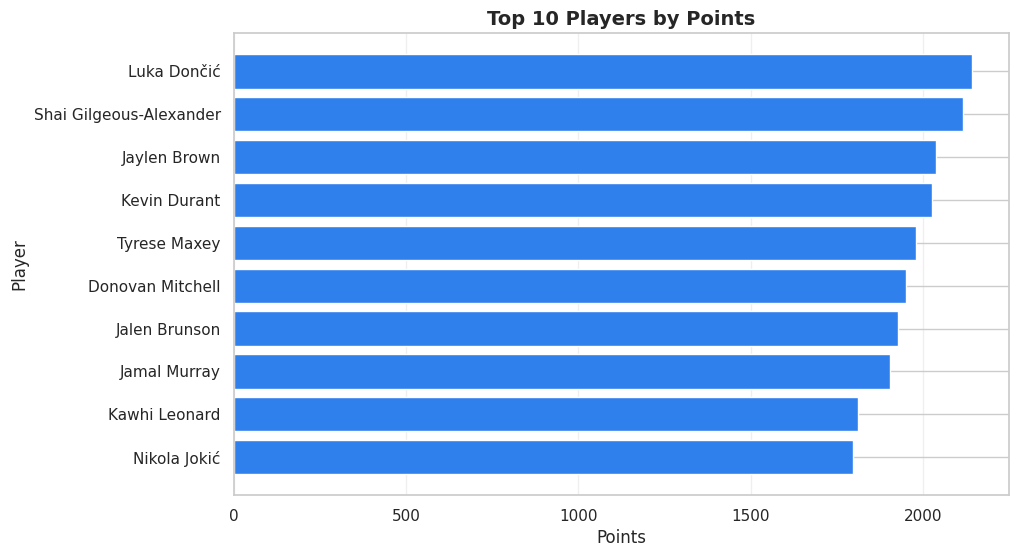

In [10]:
top_players = df_analysis.sort_values(by='Points', ascending=False).head(10)

plt.figure(figsize=(10, 6))
plt.barh(top_players['PLAYER'], top_players['Points'], color='#2f80ed')
plt.title('Top 10 Players by Points', fontsize=14, fontweight='bold')
plt.xlabel('Points')
plt.ylabel('Player')
plt.gca().invert_yaxis()
plt.grid(axis='x', alpha=0.3)
plt.show()

**Finding:** The top players have a clear scoring advantage, and even within the top 10 there are visible performance gaps.

## 10. Points Outlier Detection

The boxplot is used to identify the spread of points and detect unusually high scoring values.

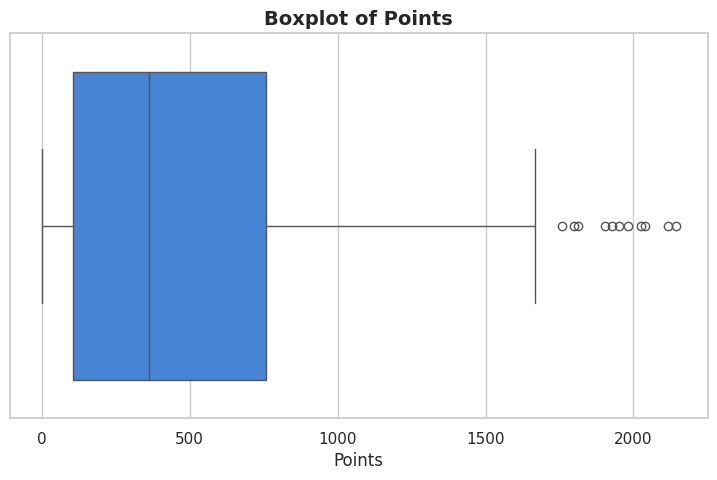

In [11]:
plt.figure(figsize=(9, 5))
sns.boxplot(x=df_analysis['Points'], color='#2f80ed')
plt.title('Boxplot of Points', fontsize=14, fontweight='bold')
plt.xlabel('Points')
plt.show()

**Finding:** The dataset contains high-scoring outliers, which represent players who stand out from the majority of the league.

## 11. Correlation Analysis

The heatmap compares relationships between the main numeric performance metrics.

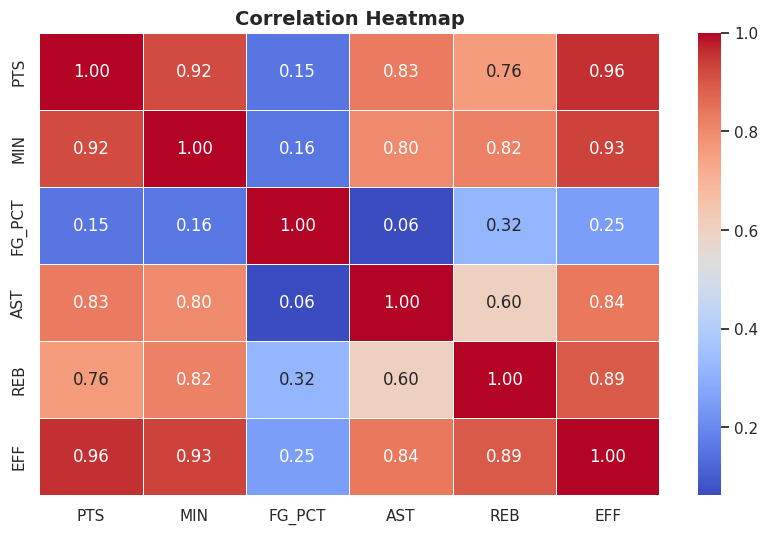

In [12]:
corr = df[performance_columns].corr()

plt.figure(figsize=(10, 6))
sns.heatmap(corr, annot=True, cmap='coolwarm', linewidths=0.5, fmt='.2f')
plt.title('Correlation Heatmap', fontsize=14, fontweight='bold')
plt.show()

**Finding:** Points are strongly related to minutes and efficiency. This suggests that both playing time and performance quality are important when evaluating scoring output.

## 12. Points Trend by Minutes

Sorting players by minutes helps visualize the general scoring trend as playing time increases.

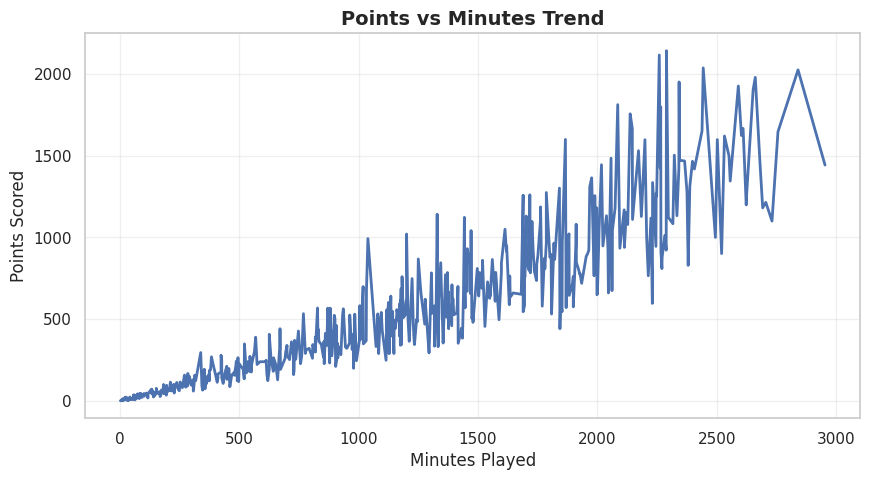

In [13]:
df_sorted = df_analysis.sort_values(by='Minutes')

plt.figure(figsize=(10, 5))
plt.plot(df_sorted['Minutes'], df_sorted['Points'], linewidth=2)
plt.title('Points vs Minutes Trend', fontsize=14, fontweight='bold')
plt.xlabel('Minutes Played')
plt.ylabel('Points Scored')
plt.grid(alpha=0.3)
plt.show()

**Finding:** The overall trend confirms that players with more minutes generally score more points.

## 13. Advanced Analysis: Average Points by Minutes Group

Players are grouped by playing time ranges to reduce noise and compare average scoring across groups.

In [14]:
df_grouped = df.copy()
df_grouped['Minutes Group'] = pd.cut(df_grouped['MIN'], bins=5)

grouped_points = (
    df_grouped
    .groupby('Minutes Group', observed=False)['PTS']
    .mean()
    .reset_index(name='Average Points')
)

grouped_points

,Minutes Group,Average Points
0,"(0.05, 593.0]",85.618182
1,"(593.0, 1183.0]",384.440945
2,"(1183.0, 1773.0]",677.675214
3,"(1773.0, 2363.0]",1064.404494
4,"(2363.0, 2953.0]",1472.931034


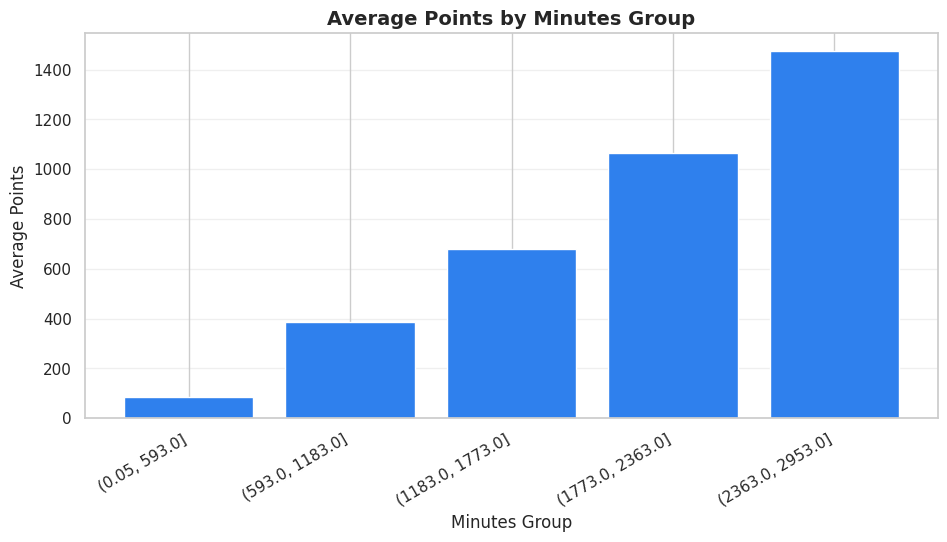

In [15]:
plt.figure(figsize=(11, 5))
plt.bar(grouped_points['Minutes Group'].astype(str), grouped_points['Average Points'], color='#2f80ed')
plt.title('Average Points by Minutes Group', fontsize=14, fontweight='bold')
plt.xlabel('Minutes Group')
plt.ylabel('Average Points')
plt.xticks(rotation=30, ha='right')
plt.grid(axis='y', alpha=0.3)
plt.show()

**Finding:** Players in higher minutes groups have higher average points, confirming the relationship seen in the earlier scatter and line charts.

## 14. Final Conclusion

This analysis shows that NBA player scoring performance is strongly associated with playing time and efficiency.

Most players score relatively low total points, while a smaller group of top performers produce much higher scoring totals. The scatter plot, line chart and grouped analysis all confirm that players who spend more time on the court generally score more points.

The correlation heatmap also shows that efficiency is important, meaning that player evaluation should consider both quantity of play and quality of performance.